# SKILLNAV : Visualisations pour la soutenance (16 figures)

> **Module** : M242 Analyse de Web · ENSA-Tétouan · Pr. Imad Sassi
> **Auteurs** : Karamo Sylla & Bachirou Konaté · **Soutenance** : 28 mai 2026
> **Prérequis** : avoir parcouru [`00_market_analysis.ipynb`](./00_market_analysis.ipynb)

---

## Objectif

Transformer les **chiffres clés** des analyses du notebook 00 en **16 figures
haute qualité** prêtes à insérer dans :

- Le rapport méthodologique L5 (rédaction Bachirou)
- Le deck PPTX de soutenance (M9-M12 démo, M13-M14 conclusion)
- Le README du repo et la page `/methodology` du dashboard Next.js

Toute la plomberie (chargement, canonicalisation, helpers, style matplotlib)
est dans le module `scripts/skillnav_eda.py`. Une seule cellule de setup
ci-dessous, puis place aux visualisations.

## Liste des 16 figures

### Vue comparative MA vs INTL (8 figures)

| # | Titre | Insight raconté                                                              |
|---|-------|------------------------------------------------------------------------------|
| F.1 | Bascule du marché              | Maroc reste Data Analytics (54 %), INTL a basculé AI-First (73 %)        |
| F.2 | Top 15 employeurs Maroc        | ESN (Capgemini, ALTEN) et banques (CIH, BNP) dominent                    |
| F.3 | Top 15 employeurs International| Finance (Capital One, Citi) + labs IA (OpenAI, Anthropic) en tête         |
| F.4 | Top 10 intitulés MA vs INTL    | Data Analyst au Maroc, AI Engineer à l'international                     |
| F.5 | Frameworks GenAI MA vs INTL    | LangChain quasi absent au Maroc (<2 %), >23 % à l'international          |
| F.6 | **Le grand écart**             | LLM +48 pts, RAG +41 pts, Prompt Engineering +37 pts en faveur de l'INTL |
| F.7 | Skills typiques marocaines     | SQL, Excel, Power BI = identité Data Analyst classique                   |
| F.8 | Recherche vs Applied           | Quelle part de R&D fondamentale dans chaque marché ?                     |

### Vues détaillées par marché (8 figures)

| #    | Titre                                          | Cible                          |
|------|------------------------------------------------|--------------------------------|
| F.9  | Distribution types Maroc (donut)               | Marché marocain stand-alone    |
| F.10 | Top 10 intitulés Maroc                         | Marché marocain stand-alone    |
| F.11 | Top 20 compétences Maroc                       | Marché marocain stand-alone    |
| F.12 | Compétences par famille Maroc (grid 5x2)       | 10 catégories détaillées MA    |
| F.13 | Distribution types International (donut)       | Marché international stand-alone |
| F.14 | Top 20 compétences International               | Marché international stand-alone |
| F.15 | Compétences par famille International          | 10 catégories détaillées INTL  |
| F.16 | Comparaison top 20 MA vs INTL (grouped bar)    | Vue directe sans calcul d'écart |


## 0. Setup


In [1]:
# Import du module utilitaire + chargement + style matplotlib (une seule cellule)
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / 'scripts'))
from skillnav_eda import *  # noqa: F401,F403

df_maroc, df_international = charger_corpus()
FIGURES_DIR = configurer_style()


Corpus chargé : 381 fiches Maroc + 3086 fiches International = 3467 total.
Style matplotlib configuré. Export PNG vers : docs\figures


---

## F.1 Bascule du marché : distribution des types de poste

> Lecture : la bar bleue indique le pourcentage d'offres marocaines de cette
> catégorie, la bar orange l'équivalent international. Plus l'écart est
> grand, plus le marché diverge sur ce profil.


  PNG sauvé : docs\figures\f01_bascule_marche.png


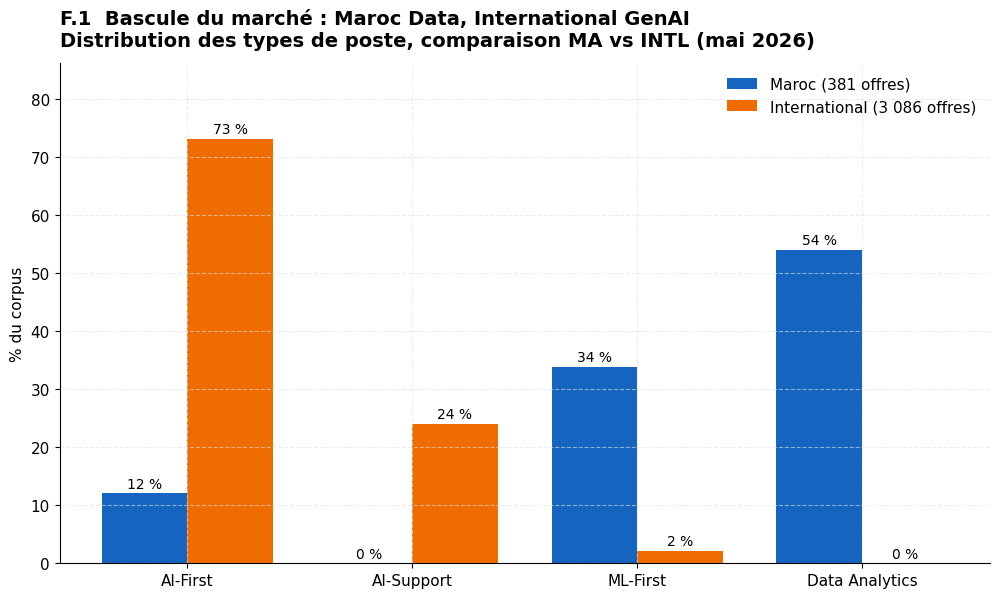

In [2]:
cnt_ma = df_maroc['ai_type'].value_counts(normalize=True) * 100
cnt_intl = df_international['ai_type'].value_counts(normalize=True) * 100
ordre = ['ai-first', 'ai-support', 'ml-first', 'non-ai']
labels = [TYPES_FR[t] for t in ordre]
vals_ma = [cnt_ma.get(t, 0) for t in ordre]
vals_intl = [cnt_intl.get(t, 0) for t in ordre]

x = np.arange(len(labels))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6.5))
b1 = ax.bar(x - width/2, vals_ma, width, label='Maroc (381 offres)', color=COULEUR_MAROC)
b2 = ax.bar(x + width/2, vals_intl, width, label='International (3 086 offres)', color=COULEUR_INTL)
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.0f} %', xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("% du corpus")
ax.set_ylim(0, max(max(vals_ma), max(vals_intl)) * 1.18)
ax.legend(loc='upper right', frameon=False)
titrer(ax, 'F.1  Bascule du marché : Maroc Data, International GenAI',
       'Distribution des types de poste, comparaison MA vs INTL (mai 2026)')

sauver_figure(fig, 'f01_bascule_marche.png')
plt.show()


---

## F.2 Qui recrute au Maroc ?

> Top 15 des entreprises qui publient le plus d'offres Data/IA au Maroc.
> Lecture rapide : ESN (Capgemini, ALTEN), banques (CIH BANK, BNP Paribas)
> et services (Agoda, BROME) dominent. Pas de purs labs IA.


  PNG sauvé : docs\figures\f02_top_employeurs_maroc.png


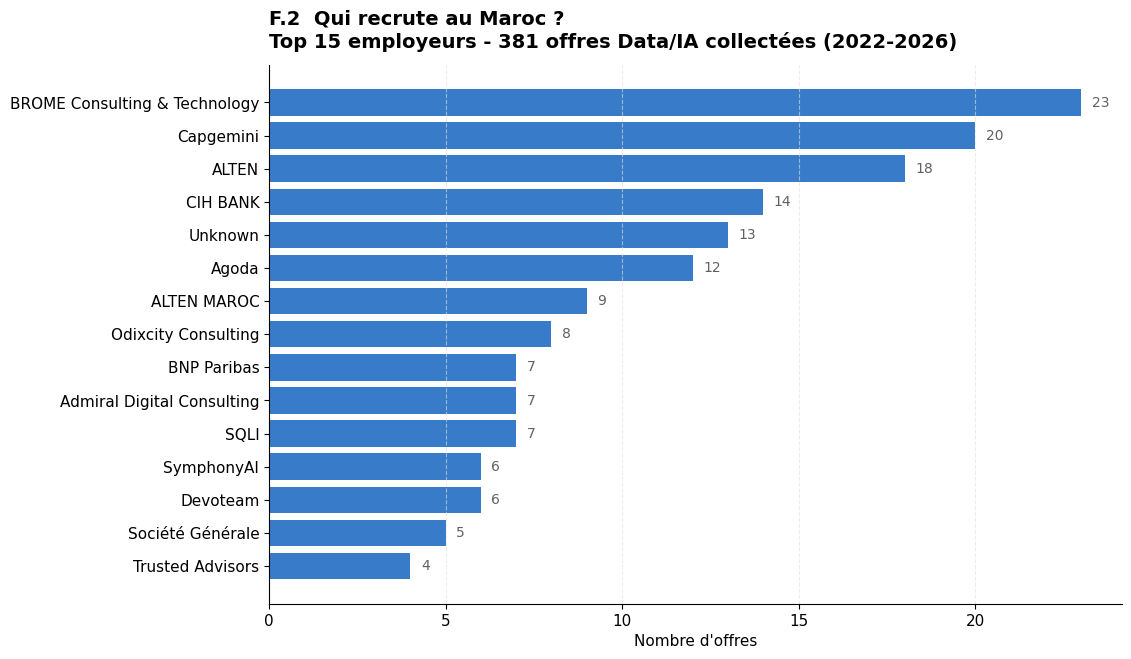

In [3]:
top15_ma = df_maroc[df_maroc['company'] != '']['company'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 7))
y = np.arange(len(top15_ma))
ax.barh(y, top15_ma.values[::-1], color=COULEUR_MAROC, alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(top15_ma.index[::-1])
ax.set_xlabel("Nombre d'offres")
for i, v in enumerate(top15_ma.values[::-1]):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=10, color=COULEUR_NEUTRE)
ax.grid(axis='y', visible=False)
titrer(ax, 'F.2  Qui recrute au Maroc ?',
       "Top 15 employeurs - 381 offres Data/IA collectées (2022-2026)")

sauver_figure(fig, 'f02_top_employeurs_maroc.png')
plt.show()


---

## F.3 Qui recrute à l'international ?

> Top 15 des entreprises qui publient le plus d'offres IA sur builtin.com.
> Mix de finance (Capital One, Citi, JP Morgan), labs IA (OpenAI, Anthropic)
> et de services tech (Thomson Reuters, NVIDIA).


  PNG sauvé : docs\figures\f03_top_employeurs_intl.png


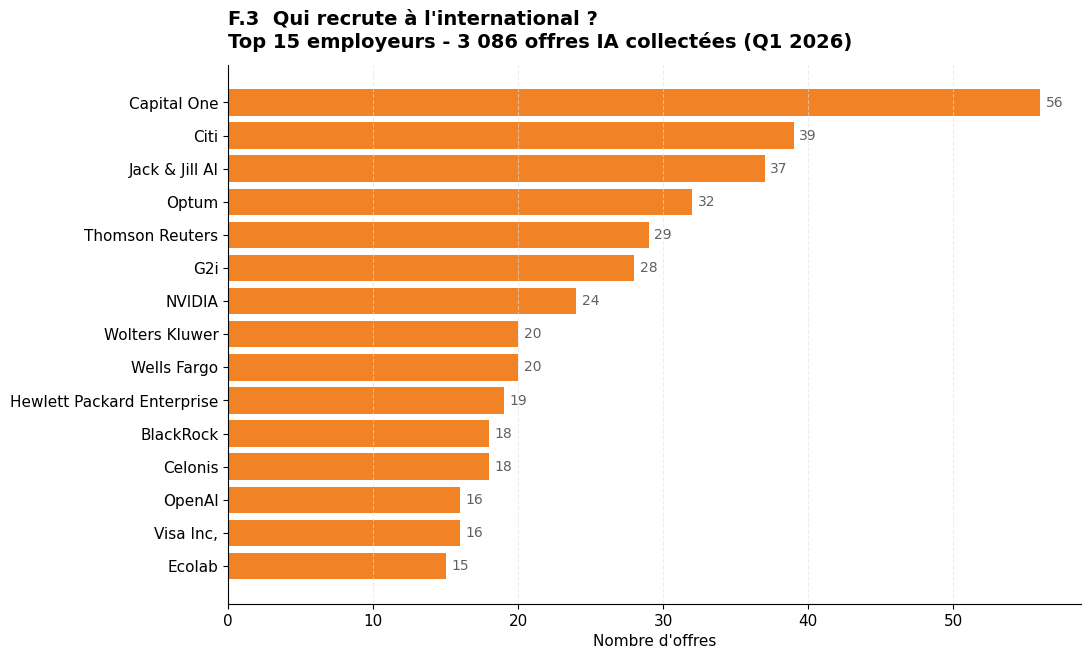

In [4]:
top15_intl = df_international[df_international['company'] != '']['company'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 7))
y = np.arange(len(top15_intl))
ax.barh(y, top15_intl.values[::-1], color=COULEUR_INTL, alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(top15_intl.index[::-1])
ax.set_xlabel("Nombre d'offres")
for i, v in enumerate(top15_intl.values[::-1]):
    ax.text(v + 0.4, i, str(v), va='center', fontsize=10, color=COULEUR_NEUTRE)
ax.grid(axis='y', visible=False)
titrer(ax, "F.3  Qui recrute à l'international ?",
       "Top 15 employeurs - 3 086 offres IA collectées (Q1 2026)")

sauver_figure(fig, 'f03_top_employeurs_intl.png')
plt.show()


---

## F.4 Le vocabulaire des métiers : MA vs INTL

> Deux sous-graphes côte à côte. À gauche les 10 intitulés les plus fréquents
> au Maroc, à droite les 10 plus fréquents à l'international.
> Le contraste **Data Analyst vs AI Engineer** saute aux yeux.


  PNG sauvé : docs\figures\f04_top_intitules.png


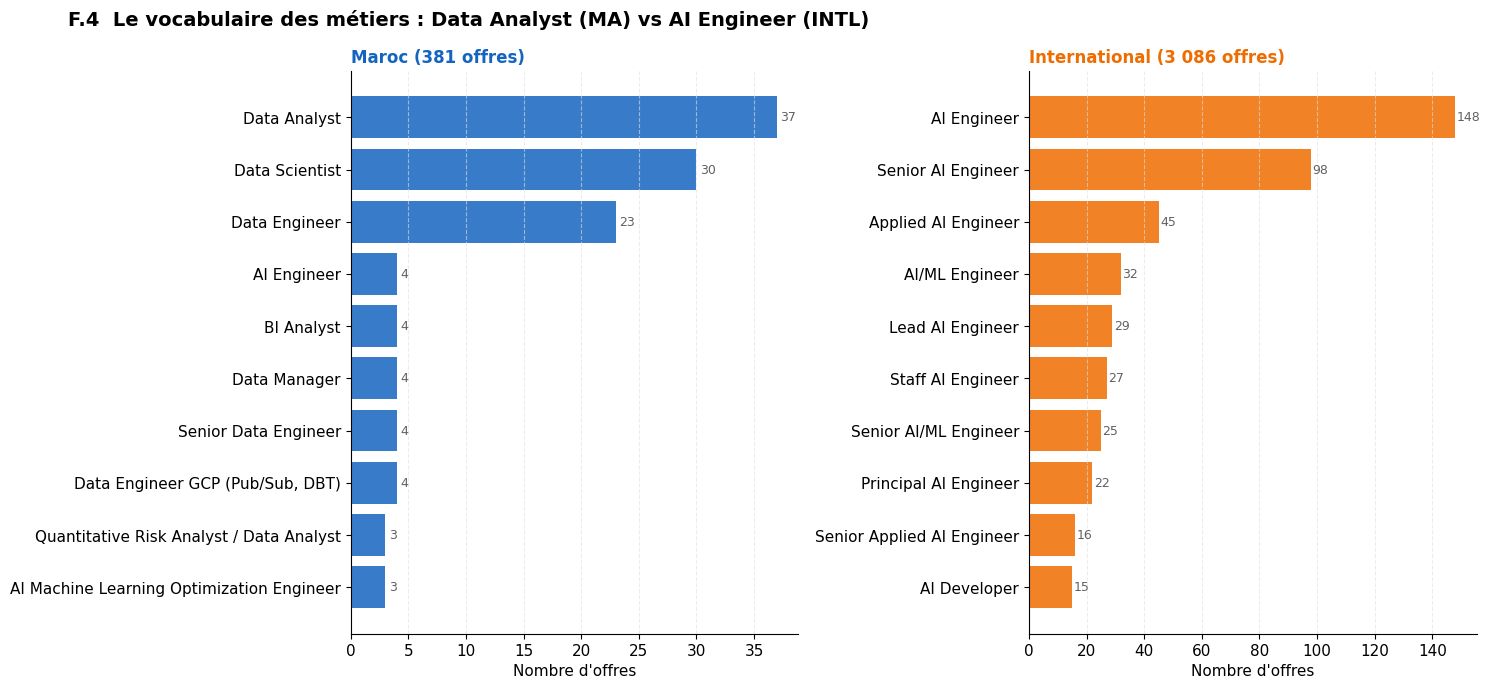

In [5]:
top10_titres_ma = df_maroc[df_maroc['title_canonical'] != '']['title_canonical'].value_counts().head(10)
top10_titres_intl = df_international[df_international['title_canonical'] != '']['title_canonical'].value_counts().head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

y1 = np.arange(len(top10_titres_ma))
ax1.barh(y1, top10_titres_ma.values[::-1], color=COULEUR_MAROC, alpha=0.85)
ax1.set_yticks(y1)
ax1.set_yticklabels(top10_titres_ma.index[::-1])
ax1.set_xlabel("Nombre d'offres")
for i, v in enumerate(top10_titres_ma.values[::-1]):
    ax1.text(v + 0.3, i, str(v), va='center', fontsize=9, color=COULEUR_NEUTRE)
ax1.grid(axis='y', visible=False)
ax1.set_title('Maroc (381 offres)', fontsize=12, fontweight='bold', color=COULEUR_MAROC, loc='left')

y2 = np.arange(len(top10_titres_intl))
ax2.barh(y2, top10_titres_intl.values[::-1], color=COULEUR_INTL, alpha=0.85)
ax2.set_yticks(y2)
ax2.set_yticklabels(top10_titres_intl.index[::-1])
ax2.set_xlabel("Nombre d'offres")
for i, v in enumerate(top10_titres_intl.values[::-1]):
    ax2.text(v + 0.5, i, str(v), va='center', fontsize=9, color=COULEUR_NEUTRE)
ax2.grid(axis='y', visible=False)
ax2.set_title('International (3 086 offres)', fontsize=12, fontweight='bold', color=COULEUR_INTL, loc='left')

fig.suptitle("F.4  Le vocabulaire des métiers : Data Analyst (MA) vs AI Engineer (INTL)",
             fontsize=14, fontweight='bold', x=0.05, ha='left')
plt.tight_layout()

sauver_figure(fig, 'f04_top_intitules.png')
plt.show()


---

## F.5 Frameworks GenAI : adoption MA vs INTL

> Bars groupées : pour chaque framework GenAI (LangChain, LangGraph,
> LlamaIndex, CrewAI, AutoGen, Haystack), le pourcentage d'offres qui le
> mentionnent au Maroc et à l'international.


  PNG sauvé : docs\figures\f05_frameworks_genai.png


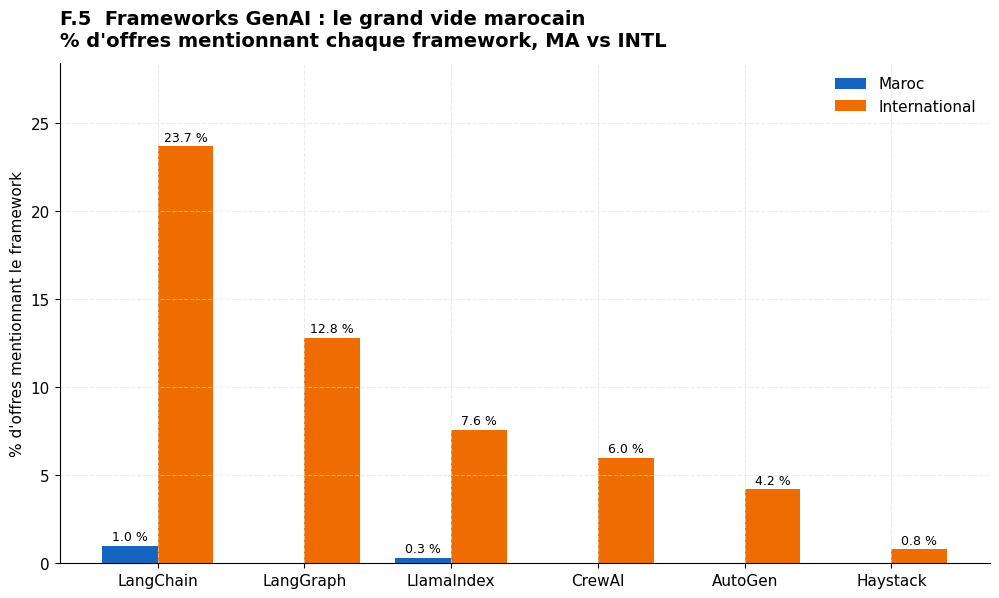

In [6]:
frameworks = ['LangChain', 'LangGraph', 'LlamaIndex', 'CrewAI', 'AutoGen', 'Haystack']
vals_ma_fw = [round(jobs_avec_skill(df_maroc, fw) / len(df_maroc) * 100, 1) for fw in frameworks]
vals_intl_fw = [round(jobs_avec_skill(df_international, fw) / len(df_international) * 100, 1) for fw in frameworks]

x = np.arange(len(frameworks))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6.5))
b1 = ax.bar(x - width/2, vals_ma_fw, width, label='Maroc', color=COULEUR_MAROC)
b2 = ax.bar(x + width/2, vals_intl_fw, width, label='International', color=COULEUR_INTL)
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.annotate(f'{h:.1f} %', xy=(bar.get_x() + bar.get_width() / 2, h),
                        xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(frameworks)
ax.set_ylabel("% d'offres mentionnant le framework")
ax.set_ylim(0, max(vals_intl_fw + [1]) * 1.2)
ax.legend(loc='upper right', frameon=False)
titrer(ax, 'F.5  Frameworks GenAI : le grand vide marocain',
       "% d'offres mentionnant chaque framework, MA vs INTL")

sauver_figure(fig, 'f05_frameworks_genai.png')
plt.show()


---

## F.6 Le grand écart : top 15 compétences INTL versus MA  (PLOT STAR)

> Diverging horizontal bar. Pour chaque compétence du top 30, on calcule
> l'écart **% INTL - % Maroc**. Les 15 plus grands écarts en faveur de l'INTL
> sont affichés en orange. C'est **la figure clé** pour M9-M12 de la
> soutenance.


  PNG sauvé : docs\figures\f06_grand_ecart_intl_vs_ma.png


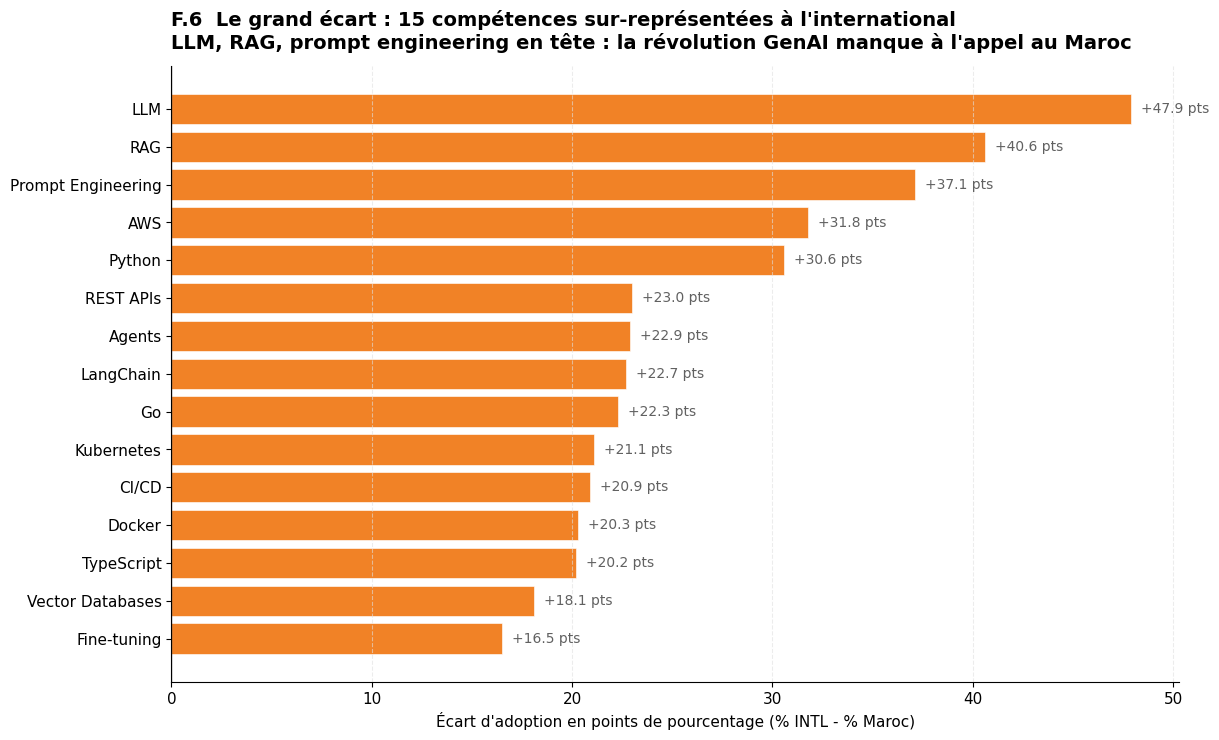

In [7]:
def comparaison_skills(df_a, df_b, top=30):
    skills_intl = top_skills_global(df_b, top=top).index.tolist()
    rows = []
    for skill in skills_intl:
        n_a = jobs_avec_skill(df_a, skill)
        n_b = jobs_avec_skill(df_b, skill)
        rows.append({
            'Compétence': skill,
            '% Maroc': round(n_a / max(len(df_a), 1) * 100, 1),
            '% INTL': round(n_b / max(len(df_b), 1) * 100, 1),
        })
    t = pd.DataFrame(rows).set_index('Compétence')
    t['Écart (% INTL - % Maroc)'] = (t['% INTL'] - t['% Maroc']).round(1)
    return t


tab50 = comparaison_skills(df_maroc, df_international, top=50)
top15_intl_skills = tab50.sort_values('Écart (% INTL - % Maroc)', ascending=False).head(15).sort_values('Écart (% INTL - % Maroc)')

fig, ax = plt.subplots(figsize=(13, 8))
y = np.arange(len(top15_intl_skills))
ecarts = top15_intl_skills['Écart (% INTL - % Maroc)'].values
ax.barh(y, ecarts, color=COULEUR_INTL, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.set_yticks(y)
ax.set_yticklabels(top15_intl_skills.index)
ax.axvline(0, color=COULEUR_NEUTRE, linewidth=1)
ax.set_xlabel("Écart d'adoption en points de pourcentage (% INTL - % Maroc)")
for i, v in enumerate(ecarts):
    ax.text(v + 0.5, i, f'+{v:.1f} pts', va='center', fontsize=10, color=COULEUR_NEUTRE)
ax.grid(axis='y', visible=False)
titrer(ax, 'F.6  Le grand écart : 15 compétences sur-représentées à l\'international',
       'LLM, RAG, prompt engineering en tête : la révolution GenAI manque à l\'appel au Maroc')

sauver_figure(fig, 'f06_grand_ecart_intl_vs_ma.png')
plt.show()


---

## F.7 Skills typiques marocaines : SQL, Excel, Power BI

> Pendant inversé de F.6. Quelles compétences sont **plus présentes au Maroc
> qu'à l'international** ?


  PNG sauvé : docs\figures\f07_skills_typiques_maroc.png


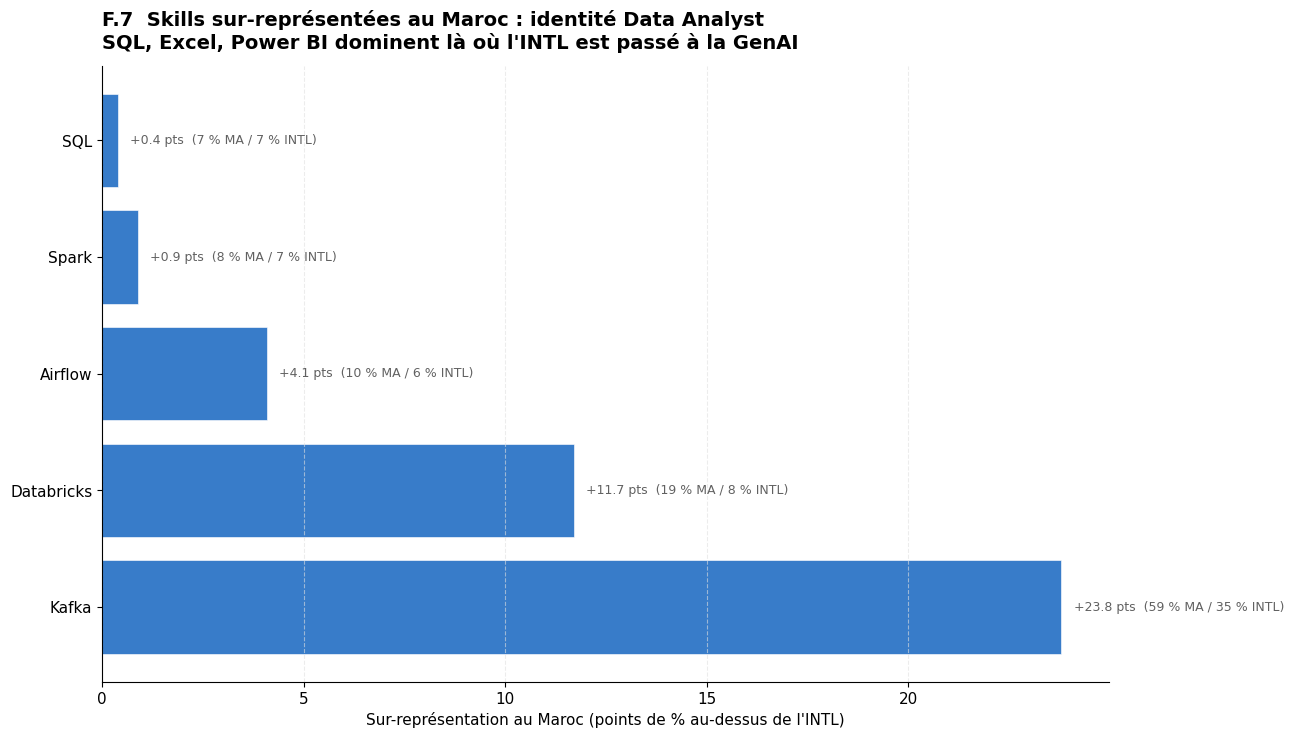

In [8]:
top15_ma_skills = tab50.sort_values('Écart (% INTL - % Maroc)', ascending=True).head(15).sort_values('Écart (% INTL - % Maroc)', ascending=False)
top15_ma_skills = top15_ma_skills[top15_ma_skills['Écart (% INTL - % Maroc)'] < 0]

fig, ax = plt.subplots(figsize=(13, 8))
y = np.arange(len(top15_ma_skills))
ecarts = top15_ma_skills['Écart (% INTL - % Maroc)'].values
ax.barh(y, -ecarts, color=COULEUR_MAROC, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.set_yticks(y)
ax.set_yticklabels(top15_ma_skills.index[::-1])
ax.invert_yaxis()
ax.set_xlabel("Sur-représentation au Maroc (points de % au-dessus de l'INTL)")
for i, v in enumerate(-ecarts):
    pct_ma = top15_ma_skills.iloc[i]['% Maroc']
    pct_intl = top15_ma_skills.iloc[i]['% INTL']
    ax.text(v + 0.3, i, f'+{v:.1f} pts  ({pct_ma:.0f} % MA / {pct_intl:.0f} % INTL)',
            va='center', fontsize=9, color=COULEUR_NEUTRE)
ax.grid(axis='y', visible=False)
titrer(ax, 'F.7  Skills sur-représentées au Maroc : identité Data Analyst',
       'SQL, Excel, Power BI dominent là où l\'INTL est passé à la GenAI')

sauver_figure(fig, 'f07_skills_typiques_maroc.png')
plt.show()


---

## F.8 Recherche vs Application / Production

> Deux donut charts côte à côte. Détection heuristique (mots-clés
> `research`, `paper`, `SOTA` vs `production`, `deploy`, `customer`).


  PNG sauvé : docs\figures\f08_recherche_vs_applied.png


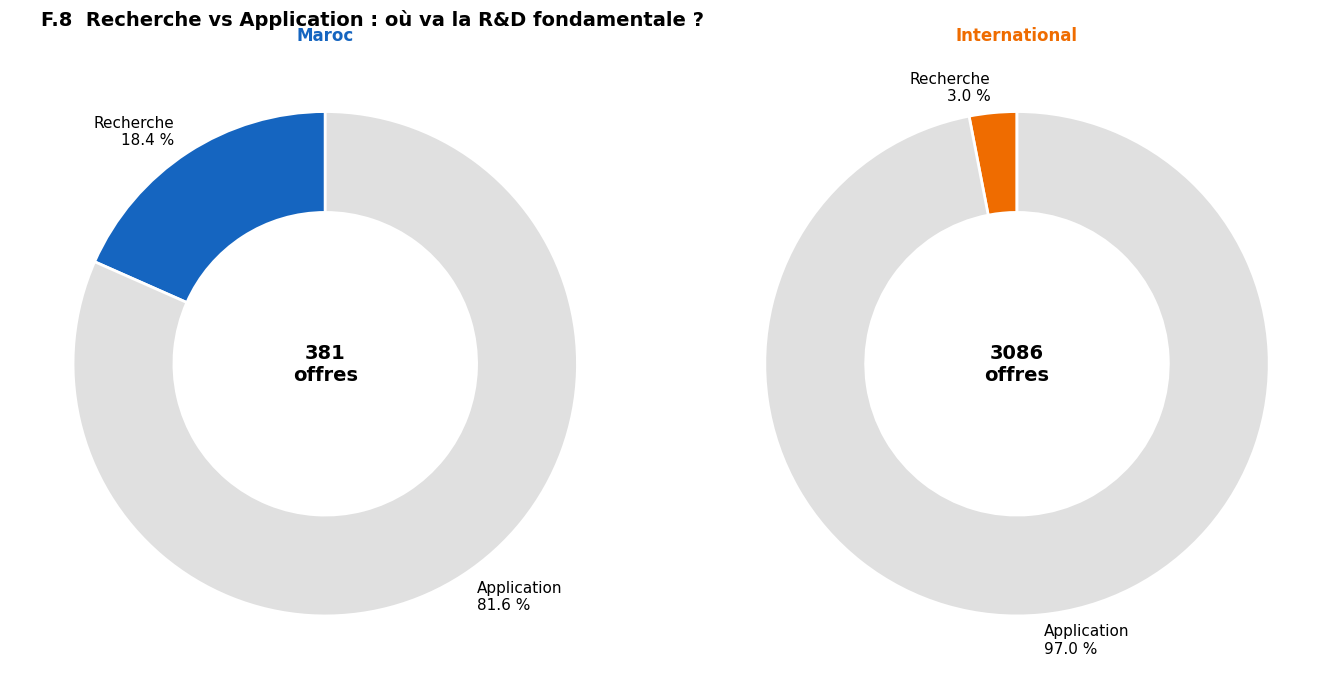

In [9]:
def part_recherche(df):
    indicateurs_recherche = ['research', 'scientist', 'publication', 'paper', 'novel', 'algorithm',
                             'state of the art', 'sota', 'reinforcement learning', 'world model']
    indicateurs_applied = ['production', 'deploy', 'shipping', 'product', 'customer', 'enterprise',
                           'api integration', 'apply', 'implement']
    def est_recherche(row):
        titre = (row['title'] or '').lower()
        resp = ' '.join(row['responsibilities']).lower()
        uc = ' '.join(row['use_cases']).lower()
        if any(kw in titre for kw in ['research engineer', 'research scientist', 'scientist']):
            return True
        texte = f'{resp} {uc}'
        r = sum(1 for kw in indicateurs_recherche if kw in texte)
        a = sum(1 for kw in indicateurs_applied if kw in texte)
        return r > a and r >= 2
    n_r = df.apply(est_recherche, axis=1).sum()
    return n_r / len(df) * 100, (len(df) - n_r) / len(df) * 100


pct_r_ma, pct_a_ma = part_recherche(df_maroc)
pct_r_intl, pct_a_intl = part_recherche(df_international)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

def trace_donut(ax, pct_r, pct_a, libelle, n_total, couleur_principal):
    parts = [pct_r, pct_a]
    labels = [f'Recherche\n{pct_r:.1f} %', f'Application\n{pct_a:.1f} %']
    couleurs = [couleur_principal, COULEUR_FOND_GRID]
    ax.pie(parts, labels=labels, colors=couleurs, startangle=90,
           wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
           textprops={'fontsize': 11})
    ax.text(0, 0, f'{n_total}\noffres', ha='center', va='center', fontsize=14, fontweight='bold')
    ax.set_title(libelle, fontsize=12, fontweight='bold', color=couleur_principal)


trace_donut(ax1, pct_r_ma, pct_a_ma, 'Maroc', len(df_maroc), COULEUR_MAROC)
trace_donut(ax2, pct_r_intl, pct_a_intl, 'International', len(df_international), COULEUR_INTL)

fig.suptitle("F.8  Recherche vs Application : où va la R&D fondamentale ?",
             fontsize=14, fontweight='bold', x=0.05, ha='left')
plt.tight_layout()

sauver_figure(fig, 'f08_recherche_vs_applied.png')
plt.show()


---

## F.9 Répartition des types de poste au Maroc

> Vue stand-alone du marché marocain. Donut chart qui montre clairement
> la dominance Data Analytics (54 %) et la marginalité des profils
> AI-First (12 %).


  PNG sauvé : docs\figures\f09_distribution_types_maroc.png


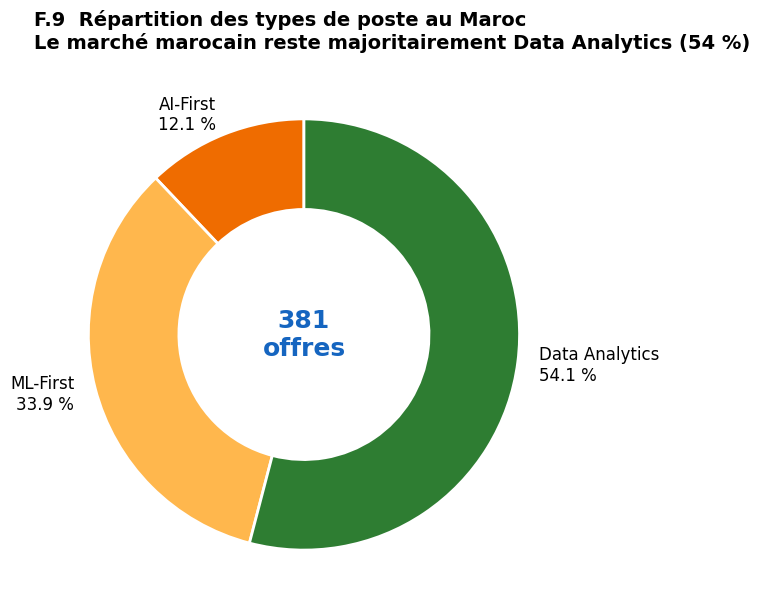

In [10]:
cnt_ma_dist = df_maroc['ai_type'].value_counts(normalize=True) * 100
ordre_d = ['ai-first', 'ai-support', 'ml-first', 'non-ai']
parts_ma = [cnt_ma_dist.get(t, 0) for t in ordre_d if cnt_ma_dist.get(t, 0) > 0]
labels_ma = [f'{TYPES_FR[t]}\n{cnt_ma_dist.get(t, 0):.1f} %' for t in ordre_d if cnt_ma_dist.get(t, 0) > 0]
couleurs_donut = [COULEUR_INTL, '#FFB74D', COULEUR_ACCENT, COULEUR_MAROC]

fig, ax = plt.subplots(figsize=(10, 7))
ax.pie(parts_ma, labels=labels_ma, colors=couleurs_donut[:len(parts_ma)],
       startangle=90, wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2),
       textprops={'fontsize': 12})
ax.text(0, 0, f'{len(df_maroc)}\noffres', ha='center', va='center',
        fontsize=18, fontweight='bold', color=COULEUR_MAROC)
titrer(ax, 'F.9  Répartition des types de poste au Maroc',
       'Le marché marocain reste majoritairement Data Analytics (54 %)')

sauver_figure(fig, 'f09_distribution_types_maroc.png')
plt.show()


---

## F.10 Top 10 intitulés de poste au Maroc (vue stand-alone)

> Pendant détaillé de F.4 : juste le Maroc, plus grand, lisible pour
> insertion dans une slide PPTX dédiée au paysage métier marocain.


  PNG sauvé : docs\figures\f10_top_intitules_maroc.png


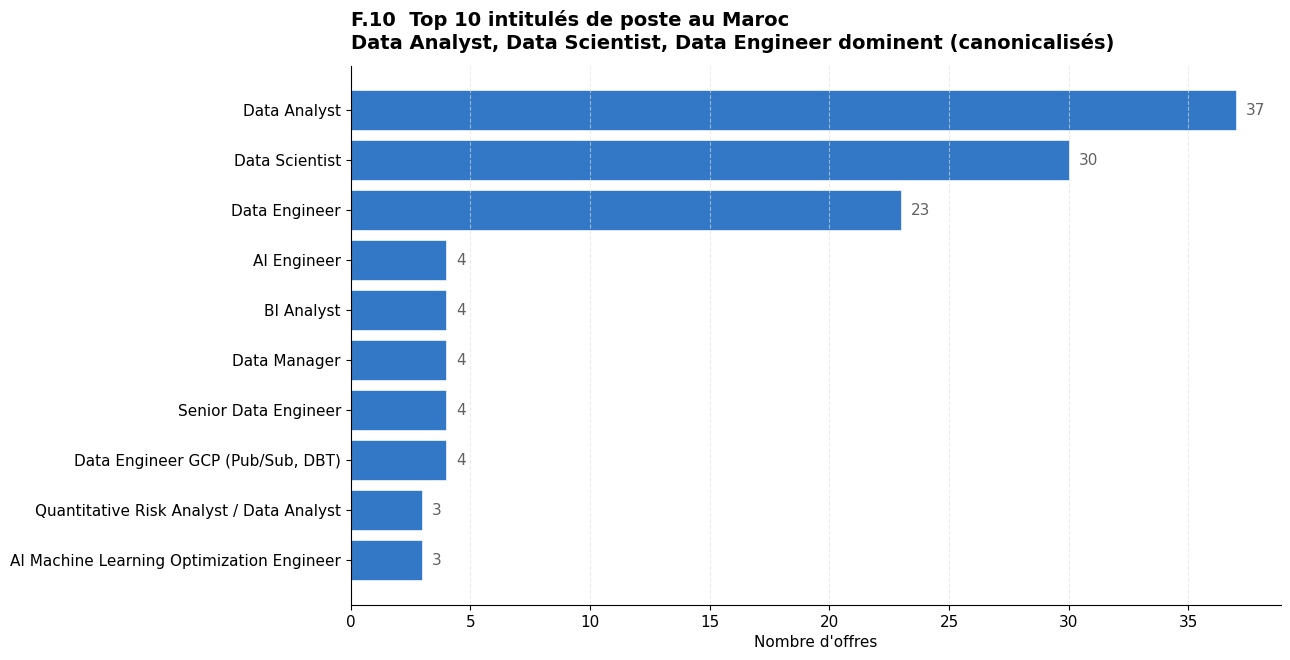

In [11]:
top10_ma = df_maroc[df_maroc['title_canonical'] != '']['title_canonical'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 7))
y = np.arange(len(top10_ma))
ax.barh(y, top10_ma.values[::-1], color=COULEUR_MAROC, alpha=0.88, edgecolor='white', linewidth=0.5)
ax.set_yticks(y)
ax.set_yticklabels(top10_ma.index[::-1])
ax.set_xlabel("Nombre d'offres")
for i, v in enumerate(top10_ma.values[::-1]):
    ax.text(v + 0.4, i, str(v), va='center', fontsize=11, color=COULEUR_NEUTRE)
ax.grid(axis='y', visible=False)
titrer(ax, 'F.10  Top 10 intitulés de poste au Maroc',
       'Data Analyst, Data Scientist, Data Engineer dominent (canonicalisés)')

sauver_figure(fig, 'f10_top_intitules_maroc.png')
plt.show()


---

## F.11 Top 20 compétences au Maroc

> Toutes familles confondues (genai + ml + cloud + ops + etc.). Vue brute
> du paysage de compétences le plus demandé sur le marché marocain.


  PNG sauvé : docs\figures\f11_top_skills_maroc.png


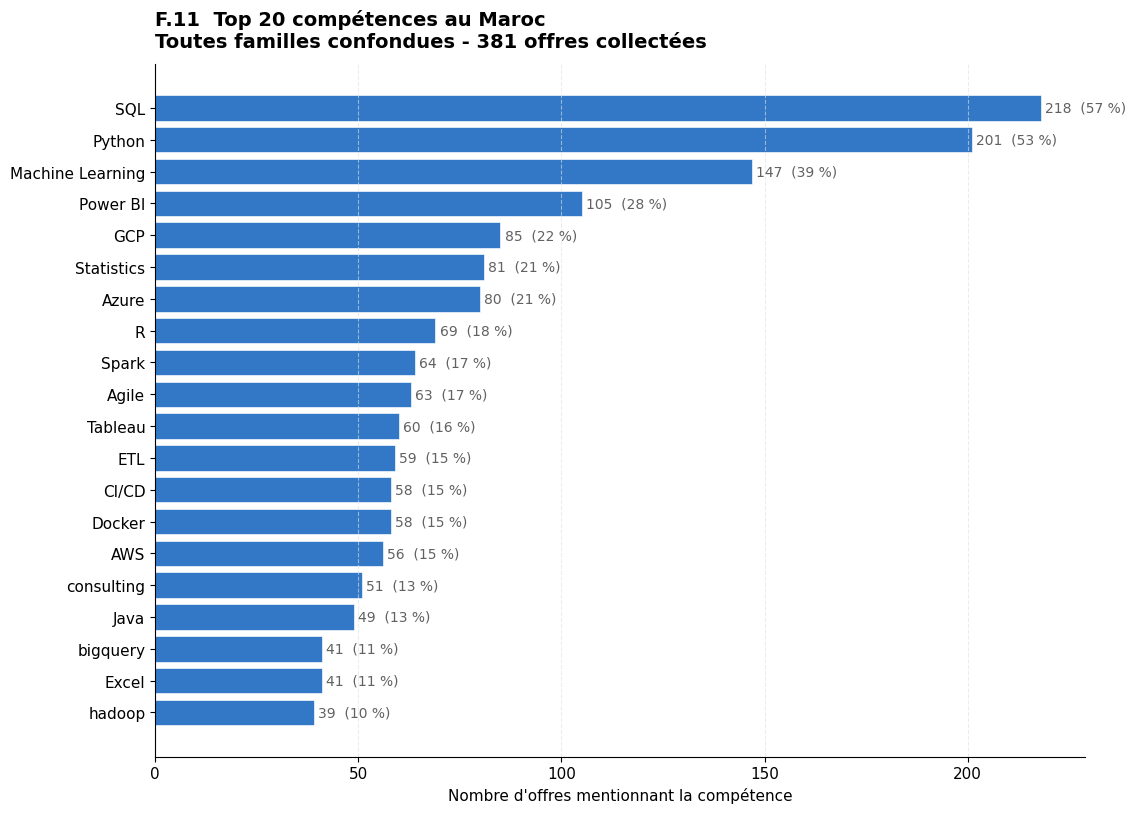

In [12]:
top20_ma_skills = top_skills_global(df_maroc, top=20)

fig, ax = plt.subplots(figsize=(12, 9))
y = np.arange(len(top20_ma_skills))
ax.barh(y, top20_ma_skills.values[::-1], color=COULEUR_MAROC, alpha=0.88, edgecolor='white', linewidth=0.5)
ax.set_yticks(y)
ax.set_yticklabels(top20_ma_skills.index[::-1])
ax.set_xlabel("Nombre d'offres mentionnant la compétence")
for i, v in enumerate(top20_ma_skills.values[::-1]):
    pct = v / len(df_maroc) * 100
    ax.text(v + 1, i, f'{v}  ({pct:.0f} %)', va='center', fontsize=10, color=COULEUR_NEUTRE)
ax.grid(axis='y', visible=False)
titrer(ax, 'F.11  Top 20 compétences au Maroc',
       'Toutes familles confondues - 381 offres collectées')

sauver_figure(fig, 'f11_top_skills_maroc.png')
plt.show()


---

## F.12 Top compétences par famille au Maroc (10 catégories)

> Grid 5x2 : un mini bar chart par famille (GenAI, ML, Web & APIs, Bases
> de données, Data Engineering, Cloud, Ops & MLOps, Langages, Domaines,
> Autres). Top 8 dans chaque famille.


  PNG sauvé : docs\figures\f12_competences_par_famille_maroc.png


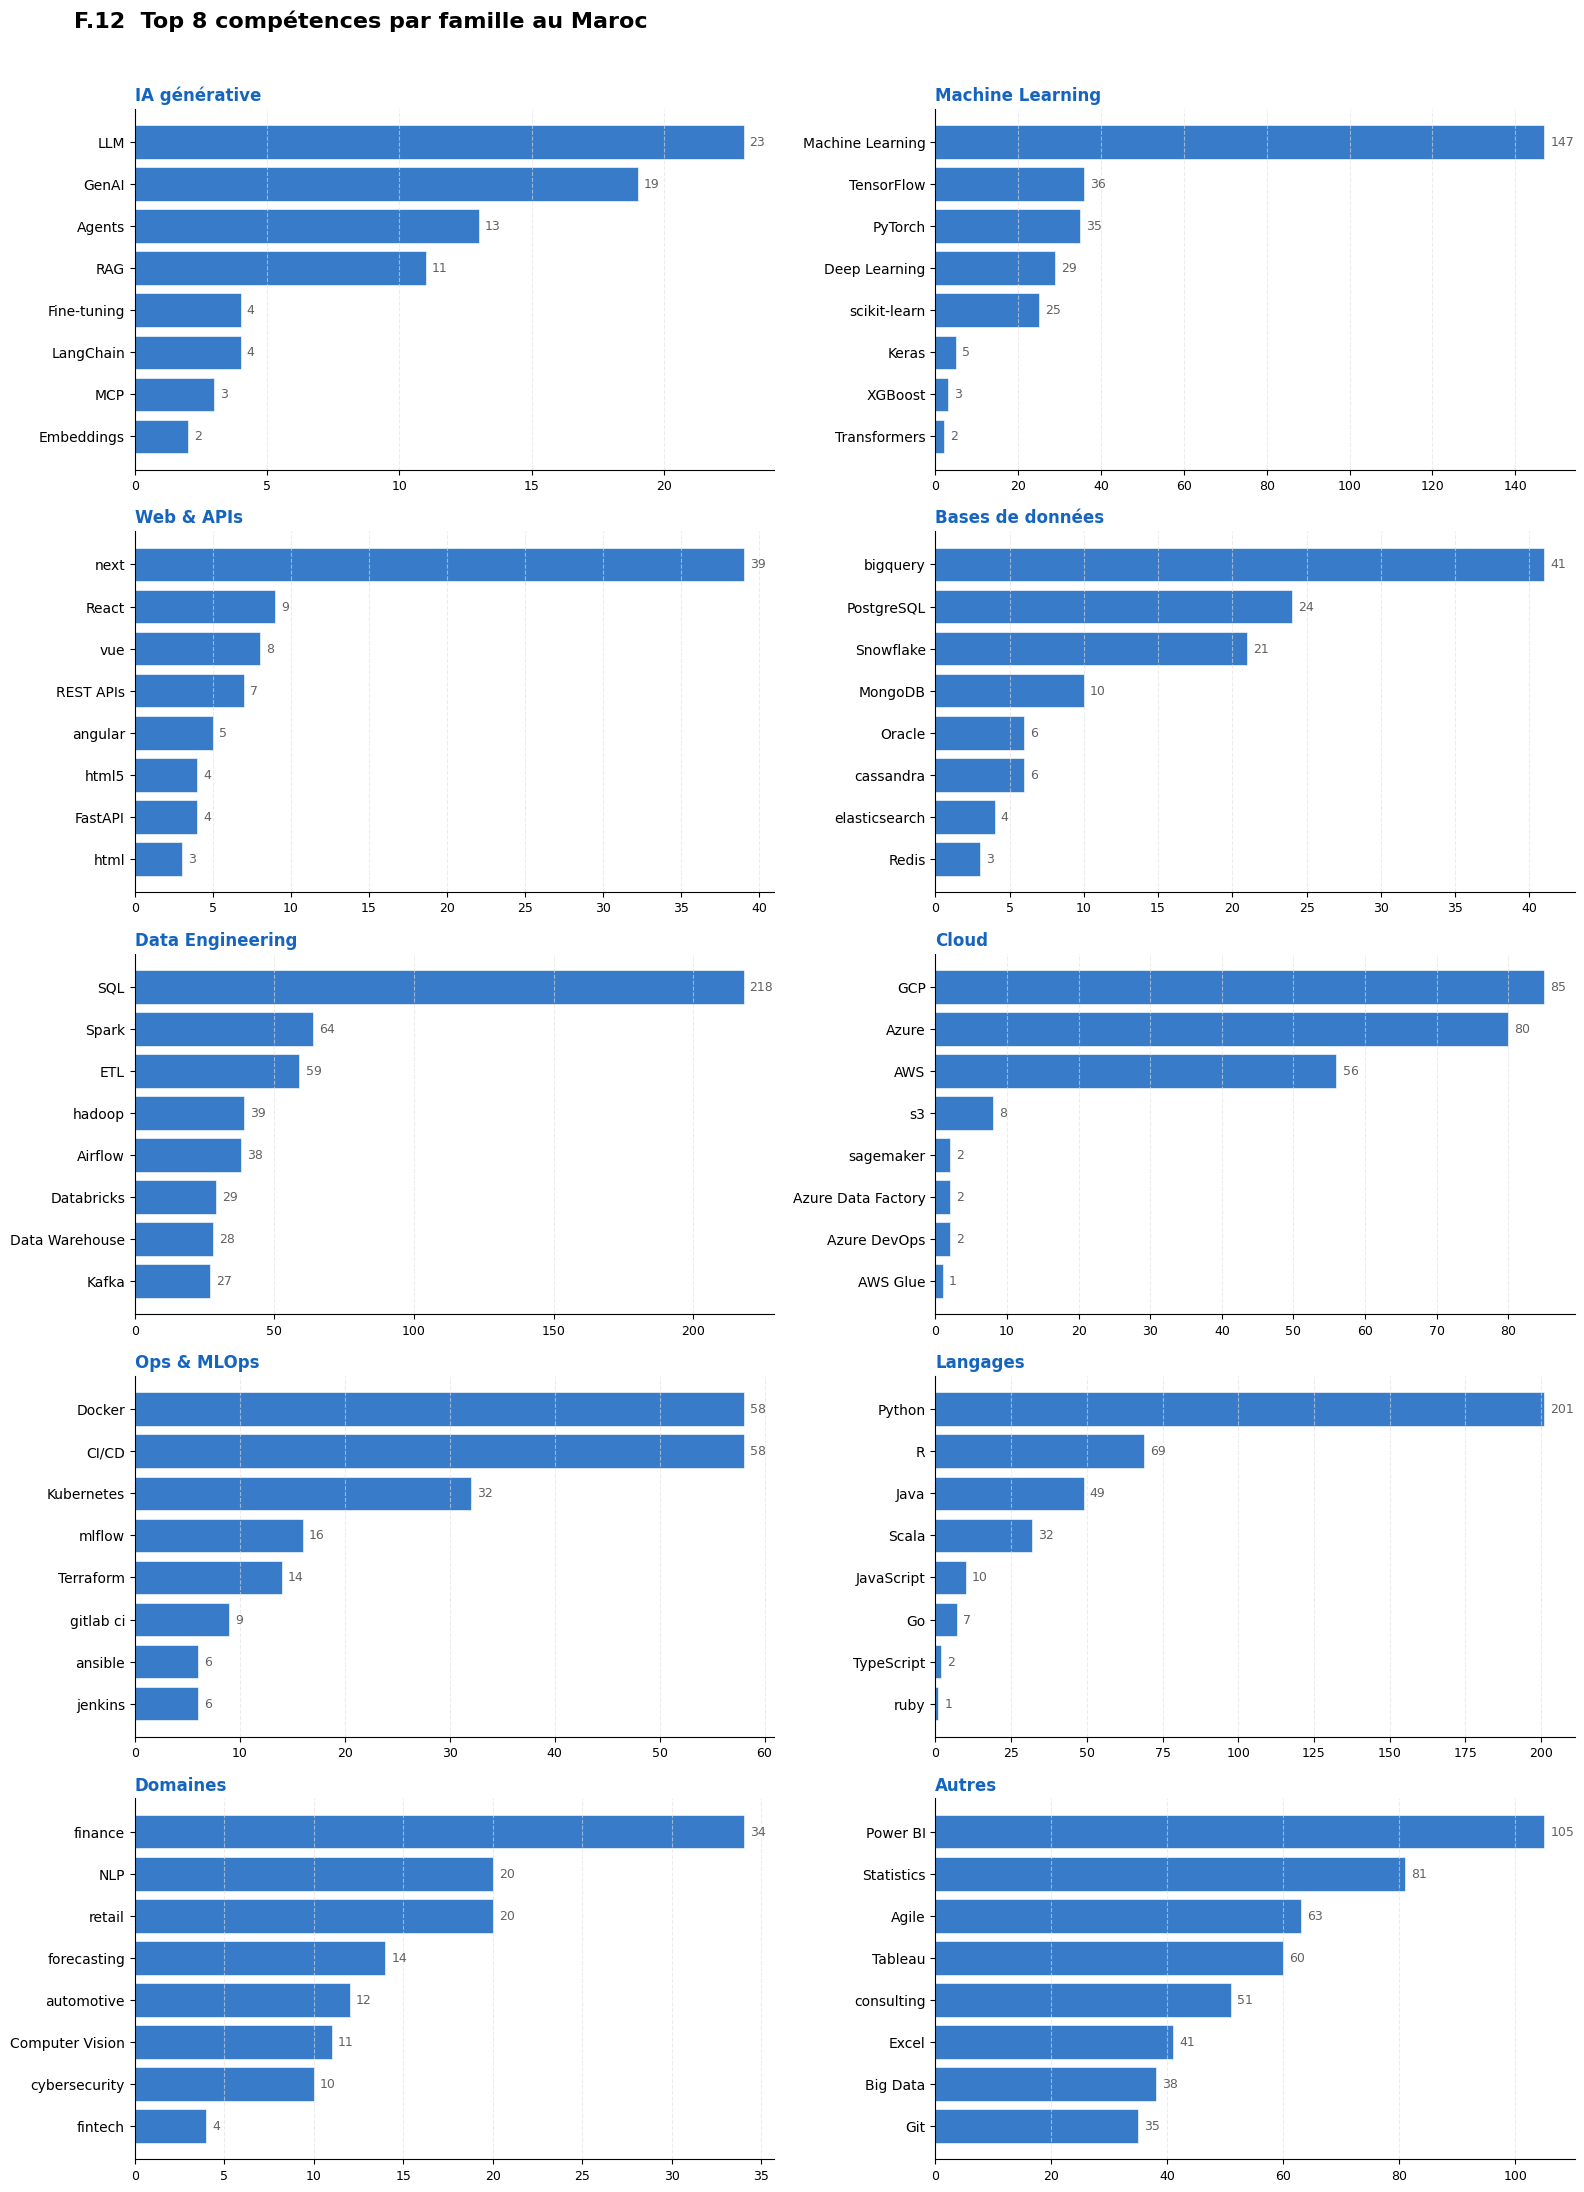

In [13]:
fig, axes = plt.subplots(5, 2, figsize=(16, 22))
axes_flat = axes.flatten()

for idx, famille in enumerate(SKILL_FAMILIES):
    ax = axes_flat[idx]
    serie = comptage_skills(df_maroc, f'skills_{famille}').head(8)
    if serie.empty:
        ax.text(0.5, 0.5, '(aucune compétence)', ha='center', va='center', fontsize=10,
                color=COULEUR_NEUTRE, transform=ax.transAxes)
        ax.set_title(FAMILLES_FR[famille], fontsize=12, fontweight='bold', color=COULEUR_MAROC, loc='left')
        ax.axis('off')
        continue
    y = np.arange(len(serie))
    ax.barh(y, serie.values[::-1], color=COULEUR_MAROC, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(serie.index[::-1], fontsize=10)
    for i, v in enumerate(serie.values[::-1]):
        ax.text(v + max(serie.values) * 0.01, i, str(v), va='center', fontsize=9, color=COULEUR_NEUTRE)
    ax.set_title(FAMILLES_FR[famille], fontsize=12, fontweight='bold', color=COULEUR_MAROC, loc='left')
    ax.grid(axis='y', visible=False)
    ax.tick_params(axis='x', labelsize=9)

fig.suptitle('F.12  Top 8 compétences par famille au Maroc',
             fontsize=16, fontweight='bold', x=0.05, ha='left', y=0.995)
plt.tight_layout(rect=(0, 0, 1, 0.985))

sauver_figure(fig, 'f12_competences_par_famille_maroc.png')
plt.show()


---

## F.13 Répartition des types de poste à l'international

> Vue stand-alone du marché international. Donut chart qui montre la
> bascule AI-First (73 %) caractéristique d'un marché tech mature en 2026.


  PNG sauvé : docs\figures\f13_distribution_types_intl.png


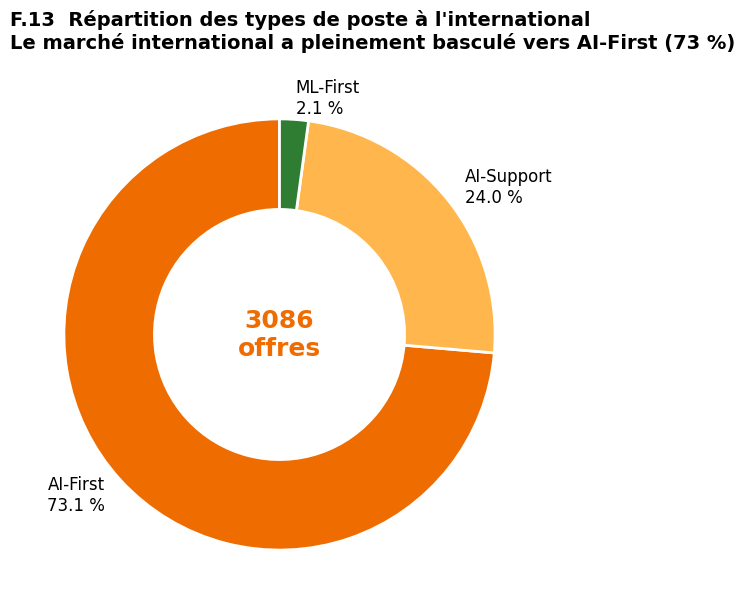

In [14]:
cnt_intl_dist = df_international['ai_type'].value_counts(normalize=True) * 100
parts_intl = [cnt_intl_dist.get(t, 0) for t in ordre_d if cnt_intl_dist.get(t, 0) > 0]
labels_intl = [f'{TYPES_FR[t]}\n{cnt_intl_dist.get(t, 0):.1f} %' for t in ordre_d if cnt_intl_dist.get(t, 0) > 0]

fig, ax = plt.subplots(figsize=(10, 7))
ax.pie(parts_intl, labels=labels_intl, colors=couleurs_donut[:len(parts_intl)],
       startangle=90, wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2),
       textprops={'fontsize': 12})
ax.text(0, 0, f'{len(df_international)}\noffres', ha='center', va='center',
        fontsize=18, fontweight='bold', color=COULEUR_INTL)
titrer(ax, "F.13  Répartition des types de poste à l'international",
       'Le marché international a pleinement basculé vers AI-First (73 %)')

sauver_figure(fig, 'f13_distribution_types_intl.png')
plt.show()


---

## F.14 Top 20 compétences à l'international

> Pendant INTL de F.11. Même méthode (toutes familles confondues), même
> format. Permet la comparaison directe avec F.11 en projection slide.


  PNG sauvé : docs\figures\f14_top_skills_intl.png


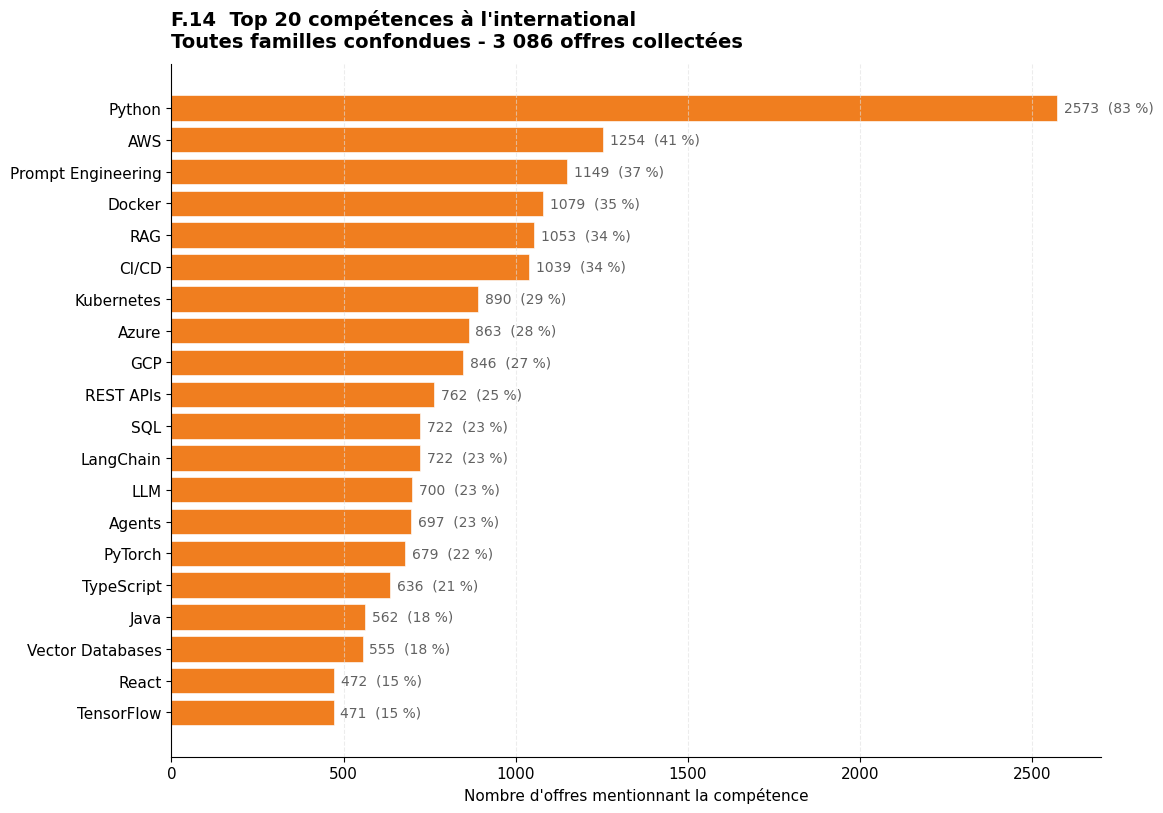

In [15]:
top20_intl_skills = top_skills_global(df_international, top=20)

fig, ax = plt.subplots(figsize=(12, 9))
y = np.arange(len(top20_intl_skills))
ax.barh(y, top20_intl_skills.values[::-1], color=COULEUR_INTL, alpha=0.88, edgecolor='white', linewidth=0.5)
ax.set_yticks(y)
ax.set_yticklabels(top20_intl_skills.index[::-1])
ax.set_xlabel("Nombre d'offres mentionnant la compétence")
for i, v in enumerate(top20_intl_skills.values[::-1]):
    pct = v / len(df_international) * 100
    ax.text(v + 20, i, f'{v}  ({pct:.0f} %)', va='center', fontsize=10, color=COULEUR_NEUTRE)
ax.grid(axis='y', visible=False)
titrer(ax, "F.14  Top 20 compétences à l'international",
       'Toutes familles confondues - 3 086 offres collectées')

sauver_figure(fig, 'f14_top_skills_intl.png')
plt.show()


---

## F.15 Top compétences par famille à l'international (10 catégories)

> Pendant INTL de F.12. Grid 5x2 avec top 8 par famille, palette orange.


  PNG sauvé : docs\figures\f15_competences_par_famille_intl.png


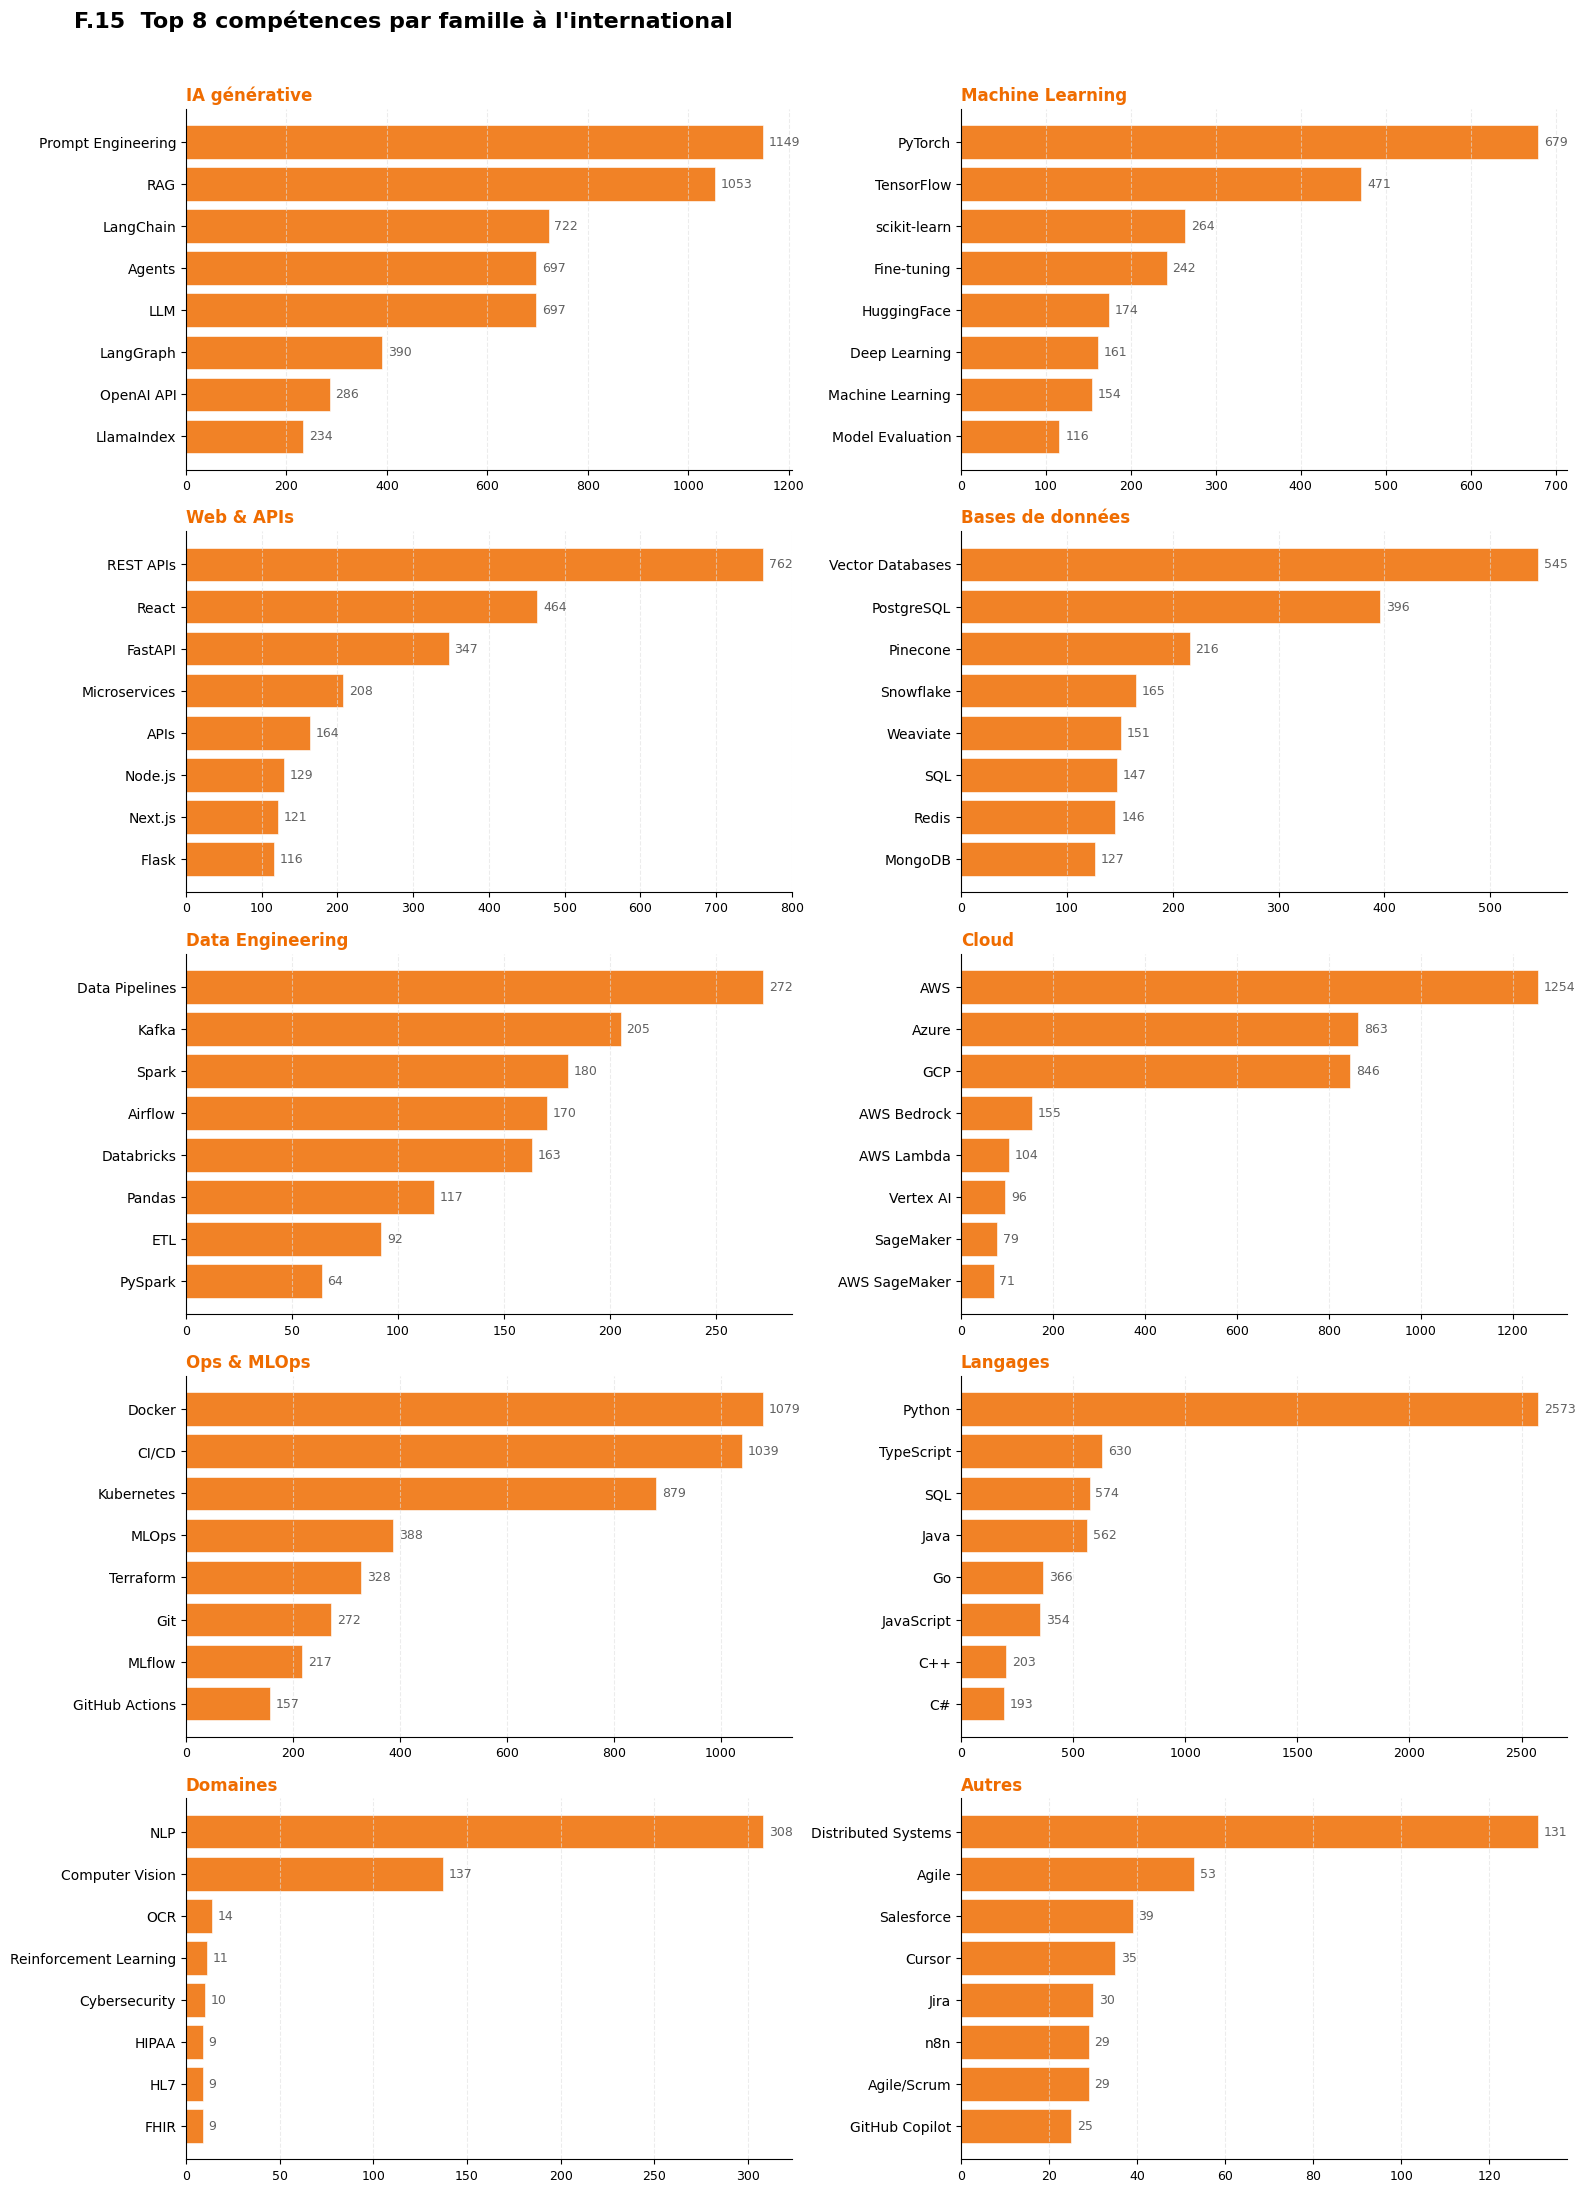

In [16]:
fig, axes = plt.subplots(5, 2, figsize=(16, 22))
axes_flat = axes.flatten()

for idx, famille in enumerate(SKILL_FAMILIES):
    ax = axes_flat[idx]
    serie = comptage_skills(df_international, f'skills_{famille}').head(8)
    if serie.empty:
        ax.text(0.5, 0.5, '(aucune compétence)', ha='center', va='center', fontsize=10,
                color=COULEUR_NEUTRE, transform=ax.transAxes)
        ax.set_title(FAMILLES_FR[famille], fontsize=12, fontweight='bold', color=COULEUR_INTL, loc='left')
        ax.axis('off')
        continue
    y = np.arange(len(serie))
    ax.barh(y, serie.values[::-1], color=COULEUR_INTL, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(serie.index[::-1], fontsize=10)
    for i, v in enumerate(serie.values[::-1]):
        ax.text(v + max(serie.values) * 0.01, i, str(v), va='center', fontsize=9, color=COULEUR_NEUTRE)
    ax.set_title(FAMILLES_FR[famille], fontsize=12, fontweight='bold', color=COULEUR_INTL, loc='left')
    ax.grid(axis='y', visible=False)
    ax.tick_params(axis='x', labelsize=9)

fig.suptitle("F.15  Top 8 compétences par famille à l'international",
             fontsize=16, fontweight='bold', x=0.05, ha='left', y=0.995)
plt.tight_layout(rect=(0, 0, 1, 0.985))

sauver_figure(fig, 'f15_competences_par_famille_intl.png')
plt.show()


---

## F.16 Comparaison Maroc vs International : top 20 compétences (vue ouverte)

> Différent de F.6 (qui montre les *écarts*) : ici, on aligne côte à côte
> le % d'adoption au Maroc (bleu) et à l'international (orange) pour les
> 20 compétences les plus fréquentes globalement.


  PNG sauvé : docs\figures\f16_comparaison_top20_ma_vs_intl.png


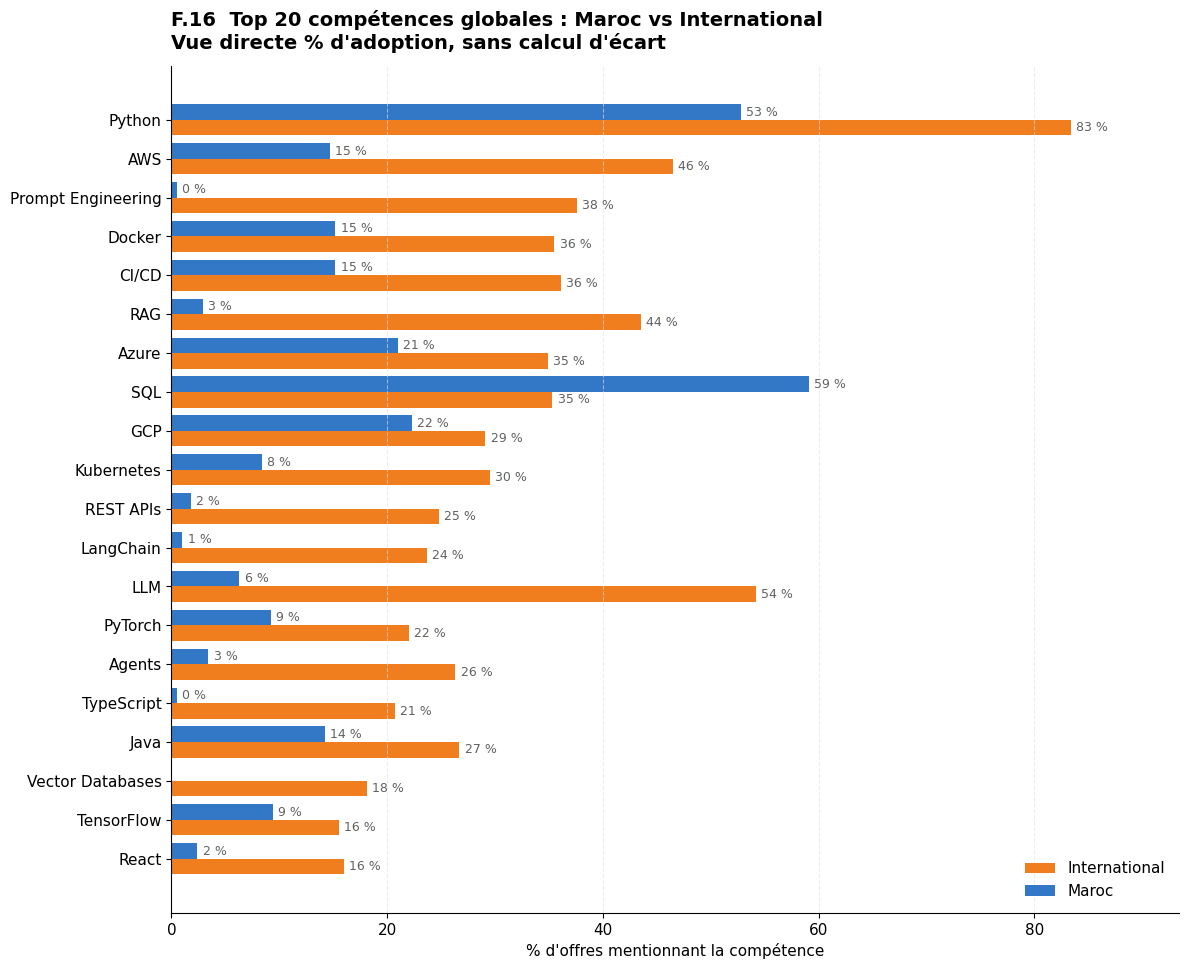

In [17]:
df_combine_tmp = pd.concat([df_maroc, df_international], ignore_index=True)
top20_global = top_skills_global(df_combine_tmp, top=20).index.tolist()

vals_ma_pct = [round(jobs_avec_skill(df_maroc, s) / len(df_maroc) * 100, 1) for s in top20_global]
vals_intl_pct = [round(jobs_avec_skill(df_international, s) / len(df_international) * 100, 1) for s in top20_global]

y = np.arange(len(top20_global))
height = 0.4

fig, ax = plt.subplots(figsize=(13, 11))
b1 = ax.barh(y - height/2, vals_intl_pct[::-1], height, label='International', color=COULEUR_INTL, alpha=0.88)
b2 = ax.barh(y + height/2, vals_ma_pct[::-1], height, label='Maroc', color=COULEUR_MAROC, alpha=0.88)

ax.set_yticks(y)
ax.set_yticklabels(top20_global[::-1])
ax.set_xlabel("% d'offres mentionnant la compétence")
ax.set_xlim(0, max(vals_intl_pct + vals_ma_pct) * 1.12)

for i, v in enumerate(vals_intl_pct[::-1]):
    if v > 0:
        ax.text(v + 0.5, i - height/2, f'{v:.0f} %', va='center', fontsize=9, color=COULEUR_NEUTRE)
for i, v in enumerate(vals_ma_pct[::-1]):
    if v > 0:
        ax.text(v + 0.5, i + height/2, f'{v:.0f} %', va='center', fontsize=9, color=COULEUR_NEUTRE)

ax.legend(loc='lower right', frameon=False, fontsize=11)
ax.grid(axis='y', visible=False)
titrer(ax, 'F.16  Top 20 compétences globales : Maroc vs International',
       "Vue directe % d'adoption, sans calcul d'écart")

sauver_figure(fig, 'f16_comparaison_top20_ma_vs_intl.png')
plt.show()


---

## Galerie : récap des 16 figures exportées


In [18]:
figures_attendues = [
    'f01_bascule_marche.png',
    'f02_top_employeurs_maroc.png',
    'f03_top_employeurs_intl.png',
    'f04_top_intitules.png',
    'f05_frameworks_genai.png',
    'f06_grand_ecart_intl_vs_ma.png',
    'f07_skills_typiques_maroc.png',
    'f08_recherche_vs_applied.png',
    'f09_distribution_types_maroc.png',
    'f10_top_intitules_maroc.png',
    'f11_top_skills_maroc.png',
    'f12_competences_par_famille_maroc.png',
    'f13_distribution_types_intl.png',
    'f14_top_skills_intl.png',
    'f15_competences_par_famille_intl.png',
    'f16_comparaison_top20_ma_vs_intl.png',
]

print(f'=== Galerie {FIGURES_DIR} ===\n')
total_ko = 0
for fname in figures_attendues:
    path = FIGURES_DIR / fname
    if path.exists():
        ko = path.stat().st_size // 1024
        total_ko += ko
        print(f'  OK  {fname:<46}  {ko:>4} Ko')
    else:
        print(f'  MANQUANT  {fname}')

print(f'\nTotal : {total_ko} Ko ({len(figures_attendues)} figures)')
print(f'Ces 16 PNG sont prêtes à coller dans le rapport L5 et le deck PPTX.')


=== Galerie F:\Web Mining Project\docs\figures ===

  OK  f01_bascule_marche.png                            73 Ko
  OK  f02_top_employeurs_maroc.png                      86 Ko
  OK  f03_top_employeurs_intl.png                       84 Ko
  OK  f04_top_intitules.png                            131 Ko
  OK  f05_frameworks_genai.png                          71 Ko
  OK  f06_grand_ecart_intl_vs_ma.png                   111 Ko
  OK  f07_skills_typiques_maroc.png                     79 Ko
  OK  f08_recherche_vs_applied.png                      85 Ko
  OK  f09_distribution_types_maroc.png                  66 Ko
  OK  f10_top_intitules_maroc.png                       89 Ko
  OK  f11_top_skills_maroc.png                         117 Ko
  OK  f12_competences_par_famille_maroc.png            311 Ko
  OK  f13_distribution_types_intl.png                   65 Ko
  OK  f14_top_skills_intl.png                          132 Ko
  OK  f15_competences_par_famille_intl.png             337 Ko
  OK  f16_comparai